# Lab Sheet 6: Extracting POS Features

Aim: To use NLP libraries to extract pos tags from text. Analyze the distribution of PoS tags and utilize them as features in downstream NLP tasks like text classification or chunking

In [2]:
import nltk
import matplotlib.pyplot as plt

In [3]:
text = "Natural Language Processing enables computers to understand human language"

tokens = nltk.word_tokenize(text)
print("Tokens: ", tokens)

pos_tags = nltk.pos_tag(tokens)
print("POS Tags: ", pos_tags)

Tokens:  ['Natural', 'Language', 'Processing', 'enables', 'computers', 'to', 'understand', 'human', 'language']
POS Tags:  [('Natural', 'JJ'), ('Language', 'NNP'), ('Processing', 'NNP'), ('enables', 'VBZ'), ('computers', 'NNS'), ('to', 'TO'), ('understand', 'VB'), ('human', 'JJ'), ('language', 'NN')]


PoS Tag Distribution:  Counter({'JJ': 2, 'NNP': 2, 'VBZ': 1, 'NNS': 1, 'TO': 1, 'VB': 1, 'NN': 1})
Tag Counts: Counter({'JJ': 2, 'NNP': 2, 'VBZ': 1, 'NNS': 1, 'TO': 1, 'VB': 1, 'NN': 1})


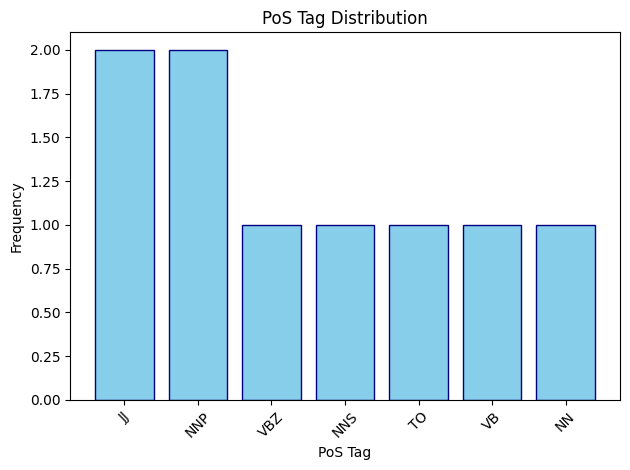

In [4]:
# Analyze POS Distribution
from collections import Counter

tag_counts = Counter(tag for word, tag in pos_tags)
print("PoS Tag Distribution: ", tag_counts)

# plot a bar graph
# Sorting the counts for the bar chart (sorted by frequency descending)
sorted_data = sorted(tag_counts.items(), key=lambda x: x[1], reverse=True)
tags, counts = zip(*sorted_data)

# Plotting
plt.bar(tags, counts, color='skyblue', edgecolor='navy')
plt.xlabel('PoS Tag')
plt.ylabel('Frequency')
plt.title('PoS Tag Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('pos_tag_distribution.png')

print("Tag Counts:", tag_counts)


In [5]:
# Use PoS Tags as Features
def pos_features(sentence): 
    tokens = nltk.word_tokenize(sentence)
    tags = [tag for word, tag in nltk.pos_tag(tokens)]

    return Counter(tags)

In [6]:
sentence_1 = "The movie was fantastic and thrilling"
sentence_2 = "The movie was boring and slow"

print("Sentence 1 Features: ", pos_features(sentence_1))
print("Sentence 2 Features: ", pos_features(sentence_2))

Sentence 1 Features:  Counter({'DT': 1, 'NN': 1, 'VBD': 1, 'JJ': 1, 'CC': 1, 'VBG': 1})
Sentence 2 Features:  Counter({'DT': 1, 'NN': 1, 'VBD': 1, 'JJ': 1, 'CC': 1, 'VB': 1})


In [7]:
# Simple Text Classification using PoS Features
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

sentences = [
    "The Product is Excellent",
    "I hated the service",
    "Amazing Experience",
    "Very disappointing",
    "Highly recommended, will buy again",
    "Worst customer service ever",
    "The battery life is phenomenal",
    "Completely stopped working after two days",
    "Beautiful design and easy to use",
    "Horrible user interface, very confusing",
    "Five stars, absolutely perfect",
    "I demand a refund immediately",
    "Fast shipping and great packaging",
    "Arrived damaged and late",
    "The sound quality is crisp and clear",
    "Too much static, unlistenable",
    "Exceeded all my expectations",
    "Barely meets the minimum requirements",
    "A joy to use every single day",
    "Frustrating and buggy software",
    "Excellent value for the price",
    "Way overpriced for what you get",
    "The material feels premium and durable",
    "Feels cheap and plasticky",
    "My new favorite gadget",
    "Belongs in the trash",
    "Setup was a breeze",
    "Took hours to figure out the instructions",
    "Friendly and helpful staff",
    "Unprofessional and rude behavior",
    "The colors are vibrant and accurate",
    "Screen is washed out and dim",
    "Keeps my coffee hot for hours",
    "Leaks everywhere, terrible design",
    "Fits perfectly, true to size",
    "Shrinks after one wash",
    "A masterpiece of modern cinema",
    "Boring plot and terrible acting",
    "Delicious food and great atmosphere",
    "Tasteless meal and dirty tables",
    "I love the new update!",
    "The latest patch ruined the game",
    "Comfortable for long walks",
    "Gave me blisters within minutes",
    "Smooth performance with no lag",
    "Constant crashes and freezes",
    "Exactly what I was looking for",
    "Nothing like the picture online",
    "Super lightweight and portable",
    "Too heavy and bulky to carry around",
    "Clear instructions, very beginner friendly",
    "Missing parts and no manual included",
    "The scent is heavenly",
    "Smells like harsh chemicals",
    "Long-lasting and reliable",
    "Flimsy and easily broken",
    "An absolute delight to read",
    "Could not get past the first chapter",
    "Great camera quality for the price",
    "Photos come out blurry and grainy"
]

labels = [
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0
]

features = [pos_features(s) for s in sentences]

In [8]:
vec = DictVectorizer()

X = vec.fit_transform(features)
model = LogisticRegression()

model.fit(X, labels)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [9]:
# Sample Predcition

test_sentence = ["I had an excellent experience"]

test_features = vec.transform([pos_features(test_sentence[0])])

prediction = model.predict(test_features)

print("Prediction:", "Positive" if prediction[0] == 1 else "Negative")

Prediction: Positive
